# GWAS Trait Spatial Localization


Use UniG cell embeddings in a gsMap-compatible trait localization workflow.


In [1]:
import os
import pickle
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
sys.path.insert(0, "/home/nas3/biod/yangchenghui/proj2/UniG_master/src")
sys.path.insert(1, "/home/nas3/biod/yangchenghui/proj2/gsMap-main/src")

import matplotlib.pyplot as plt
import scanpy as sc
import unig as ug

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sample_name = "GBM"
annotation_col = "label"
SKIP_EXISTING = True
RUN_VISUALIZATION = True
NUM_PROCESSES = 16

unig_workdir = Path("/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result")
gsmap_workdir = Path(
    "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir"
)
rna_h5ad_path = Path(
    "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_fast_workdir/UniG_GBM_RNA.h5ad"
)

mkscore_path = gsmap_workdir / sample_name / "latent_to_gene" / f"{sample_name}_gene_marker_score.feather"
latent_h5ad_path = gsmap_workdir / sample_name / "find_latent_representations" / f"{sample_name}_add_latent.h5ad"
ldsc_dir = gsmap_workdir / sample_name / "spatial_ldsc"
cauchy_dir = gsmap_workdir / sample_name / "cauchy_combination"
visualize_dir = gsmap_workdir / sample_name / "visualize"

## Load Data


In [3]:
with open(unig_workdir / "HumanGBM_UniG_adata_dict.pkl", "rb") as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata["C"]
st_RNA_adata = sc.read_h5ad(rna_h5ad_path)
st_RNA_adata, adata_C

(AnnData object with n_obs × n_vars = 2768 × 36601
     obs: 'RNA_cluster', 'COMBO_cluster', 'label'
     var: 'feature_type'
     uns: 'COMBO_cluster_colors', 'RNA_cluster_colors'
     obsm: 'spatial'
     layers: 'count',
 AnnData object with n_obs × n_vars = 2768 × 50
     obs: 'entity_anno', 'celltype', 'leiden', 'mclust'
     uns: 'neighbors', 'umap', 'leiden', 'leiden_colors', 'mclust_colors', 'celltype_colors'
     obsm: 'spatial', 'X_umap'
     obsp: 'distances', 'connectivities')

In [4]:
st_RNA_adata.obs[annotation_col].value_counts()


label
2    612
1    589
4    501
8    389
3    342
5    144
6    124
7     67
Name: count, dtype: int64

## Gene Specificity Scores


In [5]:
df_scores, adata_result = ug.trait.run_cal_GSS(
    adata_C=adata_C,
    adata_TG_expression=st_RNA_adata,
    workdir=gsmap_workdir,
    sample_name=sample_name,
    species="hg38",
    annotation_col=annotation_col,
)

df_scores.head()


Preparing data...
Expression source: 2768 cells x 30654 genes
Embedding source: 2768 cells x 50 latent dims
Species is hg38; no gene-symbol conversion performed.
Aligned cells: 2768; genes retained for GSS: 30654
latent_embedding shape: (2768, 50)
Building spatial graph...
Computing global ranks and expression background...


Ranking cells: 100%|██████████| 2768/2768 [00:03<00:00, 861.48it/s]


Calculating marker scores...


Scoring: 100%|██████████| 2768/2768 [00:28<00:00, 97.93it/s] 


Removed mitochondrial genes: 13
Feather saved to: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/latent_to_gene/GBM_gene_marker_score.feather
H5AD saved to: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/find_latent_representations/GBM_add_latent.h5ad


cell_barcode,HUMAN_GENE_SYM,AACACTTGGCAAGGAA-1,AACAGGATTCATAGTT-1,AACAGGTTATTGCACC-1,AACAGGTTCACCGAAG-1,AACAGTCAGGCTCCGC-1,AACAGTCGTGTCGCGG-1,AACATATTCTTGCGAA-1,AACATCGCGTGACCAC-1,AACATCTAATGACCGG-1,...,TGTTCAGAACGGTGTA-1,TGTTCATAGTATGACG-1,TGTTCATTGGTCCAAG-1,TGTTCCTCACATTAAT-1,TGTTCTGCTCTGTCGT-1,TGTTGCGTCCAAGATT-1,TGTTGGAACCTTCCGC-1,TGTTGGAACGAGGTCA-1,TGTTGGCCAGACCTAC-1,TGTTGGCCTACACGTG-1
0,AL627309.1,0.00,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AL627309.5,0.00,0.0,0.000000,0.0,0.0,0.0,0.000000,1.816406,0.0,...,0.0,0.0,1.84375,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AP006222.2,0.00,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AL669831.2,0.00,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,LINC01409,1.75,0.0,1.841797,0.0,0.0,0.0,1.899414,1.791016,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## LD Score


In [8]:
ug.trait.patch_plink_next_snps()

abc_enhancer_bed = Path(
    "/home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/genome_annotation/enhancer/by_tissue/ALL/ABC_roadmap_merged.bed"
)

if not mkscore_path.exists():
    raise FileNotFoundError(f"mkscore not found: {mkscore_path}. Run the GSS step first.")

ldscore_config = ug.trait.generate_ldscore(
    workdir=gsmap_workdir,
    sample_name=sample_name,
    abc_enhancer_bed=abc_enhancer_bed,
    bfile_root="/home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/LD_Reference_Panel/1000G_EUR_Phase3_plink/1000G.EUR.QC",
    keep_snp_root="/home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/LDSC_resource/hapmap3_snps/hm",
    gtf_annotation_file="/home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/genome_annotation/gtf/gencode.v46lift37.basic.annotation.gtf",
    gene_window_size=50000,
    spots_per_chunk=3000,
)

[2026-08-30 20:15:16,743] INFO | gsMap - Both gene_window and enhancer annotation will be used to calculate LD score. 
[2026-08-30 20:15:16,744] INFO | gsMap - SNP within +-50000 bp of gene body will be used and enhancer annotation will be used to calculate LD score. If a snp maps to multiple enhancers, the strategy to choose by your select strategy: max_mkscore.
[2026-08-30 20:15:16,744] INFO | gsMap - ------Baseline annotation is not provided. Default baseline annotation will be used.


[PATCH] PlinkBEDFile.nextSNPs compatibility patch applied.
[RUN] generate_ldscore


[2026-08-30 20:15:17,208] INFO | gsMap.generate_ldscore - Loading GTF data from /home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/genome_annotation/gtf/gencode.v46lift37.basic.annotation.gtf
[2026-08-30 20:16:35,610] INFO | gsMap.generate_ldscore - Found 21516 common genes between GTF and marker scores
[2026-08-30 20:16:38,320] INFO | gsMap.generate_ldscore - Processing chromosome 1
[2026-08-30 20:16:39,748] INFO | gsMap.utils.plink_ldscore_tool - Loading Plink genotype data from /home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/LD_Reference_Panel/1000G_EUR_Phase3_plink/1000G.EUR.QC.1.bed
[2026-08-30 20:16:42,798] INFO | gsMap.utils.plink_ldscore_tool - Calculating MAF and QC for all SNPs
[2026-08-30 20:16:46,569] INFO | gsMap.utils.plink_ldscore_tool - All SNPs passed the basic quality check
[2026-08-30 20:16:47,143] INFO | gsMap.utils.plink_ldscore_tool - Loaded genotype data with 779354 SNPs and 489 individuals
[2026-08-30 20:16:47,172] 

[DONE] LD score generated at: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/generate_ldscore


## Trait Inputs


In [9]:
TRAIT_SUMSTATS = {
    "Brain_glioblastoma": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Brain_glioblastoma/finn-b-C3_GBM_EXALLC.gsMap.sumstats.gz",
    "Brain_tumor": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Brain_tumor/ebi-a-GCST90018800.gsMap.sumstats.gz",
    "Malignant_neoplasm_of_brain": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Malignant_neoplasm_of_brain/finn-b-C3_BRAIN.gsMap.sumstats.gz",
    "Cognitive_performance": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Cognitive_performance/ebi-a-GCST006572.gsMap.sumstats.gz",
    "Delayed_neurodevelopment": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Delayed_neurodevelopment/GCST90319900.gsMap.sumstats.gz",
    "Educational_attainment": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Educational_attainment/ebi-a-GCST90029013.gsMap.sumstats.gz",
    "Childhood_intelligence": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Childhood_intelligence/ieu-a-16.gsMap.sumstats.gz",
    "Autism_Spectrum_Disorder": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Autism_Spectrum_Disorder/ieu-a-1185.gsMap.sumstats.gz",
    "Schizophrenia": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Schizophrenia/ieu-b-5102.gsMap.sumstats.gz",
    "ADHD": "/home/nas3/biod/yangchenghui/proj2/gwas_data/ADHD/ieu-a-1183.gsMap.sumstats.gz",
    "scz": "/home/nas3/biod/yangchenghui/proj2/proj2_on_haima/gwas/Schizophrenia.sumstats.gz",
    "Intracranial_volume": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Intracranial_volume/ieu-a-1041.gsMap.sumstats.gz",
    "Cerebral_WhiteMatter_volume": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Cerebral_WhiteMatter_volume/ieu-a-2702.gsMap.sumstats.gz",
    "Brain_volume": "/home/nas3/biod/yangchenghui/proj2/gwas_data/Brain_volume/ubm-a-9.gsMap.sumstats.gz",
}

missing_sumstats = {
    trait: path
    for trait, path in TRAIT_SUMSTATS.items()
    if not Path(path).exists()
}
if missing_sumstats:
    details = "\\n".join(f"  {trait}: {path}" for trait, path in missing_sumstats.items())
    raise FileNotFoundError(f"Missing sumstats files:\\n{details}")

print(f"Configured {len(TRAIT_SUMSTATS)} traits.")


Configured 14 traits.


## Spatial LDSC


In [10]:
spatial_ldsc_outputs = ug.trait.batch_spatial_ldsc(
    trait_sumstats=TRAIT_SUMSTATS,
    workdir=gsmap_workdir,
    sample_name=sample_name,
    w_file="/home/nas3/biod/yangchenghui/proj2/gsMap_Reproduction_ych/gsMap_resource/LDSC_resource/weights_hm3_no_hla/weights.",
    num_processes=NUM_PROCESSES,
    skip_existing=SKIP_EXISTING,
)

spatial_ldsc_outputs


[SKIP] Spatial LDSC already exists for Brain_glioblastoma: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Brain_glioblastoma.csv.gz
[SKIP] Spatial LDSC already exists for Brain_tumor: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Brain_tumor.csv.gz
[SKIP] Spatial LDSC already exists for Malignant_neoplasm_of_brain: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Malignant_neoplasm_of_brain.csv.gz
[SKIP] Spatial LDSC already exists for Cognitive_performance: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Cognitive_performance.csv.gz
[SKIP] Spatial LDSC already exists for Delayed_neurodevelopment: /home/nas3/biod/yangchenghui/

{'Brain_glioblastoma': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Brain_glioblastoma.csv.gz'),
 'Brain_tumor': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Brain_tumor.csv.gz'),
 'Malignant_neoplasm_of_brain': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Malignant_neoplasm_of_brain.csv.gz'),
 'Cognitive_performance': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Cognitive_performance.csv.gz'),
 'Delayed_neurodevelopment': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/spatial_ldsc/GBM_Del

## Cauchy Combination


In [11]:
cauchy_summary, cauchy_outputs = ug.trait.batch_cauchy_combination(
    trait_sumstats=TRAIT_SUMSTATS,
    workdir=gsmap_workdir,
    sample_name=sample_name,
    annotation_col=annotation_col,
    skip_existing=SKIP_EXISTING,
)

cauchy_summary


[SKIP] Cauchy result already exists for Brain_glioblastoma: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_Brain_glioblastoma.Cauchy.csv.gz
[SKIP] Cauchy result already exists for Brain_tumor: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_Brain_tumor.Cauchy.csv.gz
[SKIP] Cauchy result already exists for Malignant_neoplasm_of_brain: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_Malignant_neoplasm_of_brain.Cauchy.csv.gz
[SKIP] Cauchy result already exists for Cognitive_performance: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_Cognitive_performance.Cauchy.csv.gz
[SKIP] Cauchy result already exists fo

,trait,annotation,p_cauchy,p_median
0,Brain_glioblastoma,7,0.126415,0.290712
1,Brain_glioblastoma,5,0.545449,0.475537
2,Brain_glioblastoma,6,0.787611,0.641329
3,Brain_glioblastoma,1,0.896550,0.686173
4,Brain_glioblastoma,3,0.900209,0.818548
...,...,...,...,...
107,Brain_volume,3,0.131484,0.240267
108,Brain_volume,1,0.170816,0.283338
109,Brain_volume,2,0.193762,0.337431
110,Brain_volume,7,0.252409,0.343702


## Visualization


In [12]:
if RUN_VISUALIZATION:
    visualize_outputs = ug.trait.batch_visualization(
        trait_sumstats=TRAIT_SUMSTATS,
        workdir=gsmap_workdir,
        sample_name=sample_name,
        annotation_col=annotation_col,
        skip_existing=SKIP_EXISTING,
        point_size=5,
        fig_width=900,
        fig_height=700,
    )
else:
    visualize_outputs = {}
    print("RUN_VISUALIZATION=False; skipped batch visualization.")

visualize_outputs


[SKIP] Visualization already exists for Brain_glioblastoma: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Brain_glioblastoma.html
[SKIP] Visualization already exists for Brain_tumor: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Brain_tumor.html
[SKIP] Visualization already exists for Malignant_neoplasm_of_brain: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Malignant_neoplasm_of_brain.html
[SKIP] Visualization already exists for Cognitive_performance: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Cognitive_performance.html
[SKIP] Visualization already exists for Delayed_neurodevelopment: /home/nas3/biod/yangchenghui/proj2/proj2_on_

{'Brain_glioblastoma': {'html': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Brain_glioblastoma.html'),
  'csv': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Brain_glioblastoma.csv')},
 'Brain_tumor': {'html': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Brain_tumor.html'),
  'csv': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Brain_tumor.csv')},
 'Malignant_neoplasm_of_brain': {'html': PosixPath('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/visualize/GBM_Malignant_neoplasm_of_brain.html'),
  'csv': PosixPath(

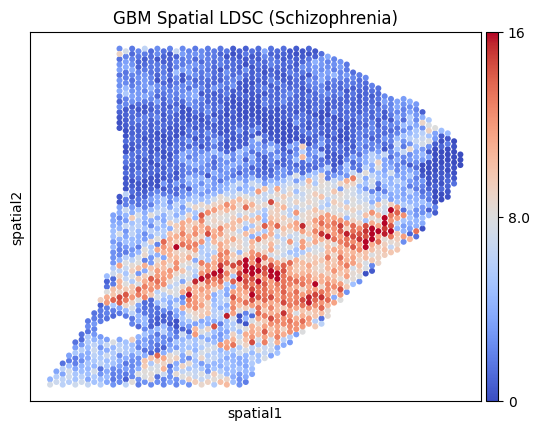

In [15]:
plot_trait = "Schizophrenia"

fig, trait_adata = ug.trait.plot_trait_spatial_score(
    trait_name=plot_trait,
    workdir=gsmap_workdir,
    sample_name=sample_name,
    output_path=f"/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/figures/GBM_Spatial_LDSC_{plot_trait}.pdf",
    color_col="logp",
    size=75,
    cmap="coolwarm",
    vmin=0,
    vmax=16,
)


## Cluster x Trait Heatmap


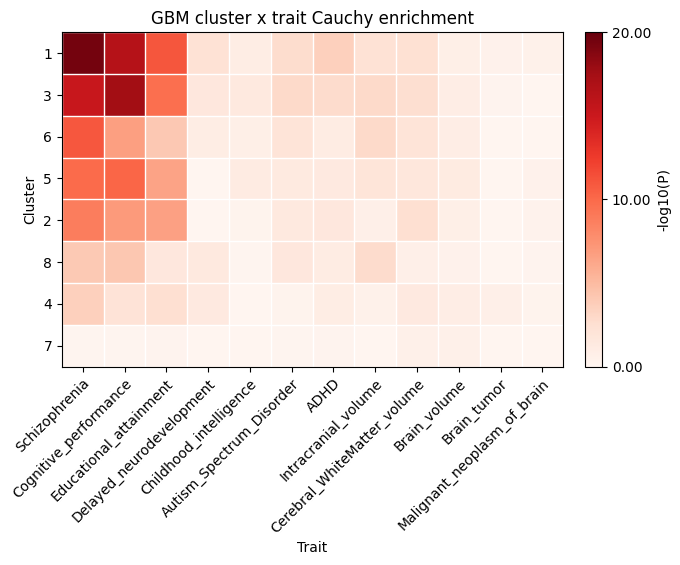

clusters=8
traits=12
matrix_csv=/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_cluster_trait_cauchy_neglog10P_heatmap.matrix.csv
long_csv=/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_cluster_trait_cauchy_neglog10P_heatmap.long.csv
png=/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_cluster_trait_cauchy_neglog10P_heatmap.png
pdf=/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/trait_localization_output/gsmap_step_by_step_workdir/GBM/cauchy_combination/GBM_cluster_trait_cauchy_neglog10P_heatmap.pdf


trait,Schizophrenia,Cognitive_performance,Educational_attainment,Delayed_neurodevelopment,Childhood_intelligence,Autism_Spectrum_Disorder,ADHD,Intracranial_volume,Cerebral_WhiteMatter_volume,Brain_volume,Brain_tumor,Malignant_neoplasm_of_brain
cluster,,,,,,,,,,,,
1,19.404112,16.388484,11.090565,2.253460,1.013721,2.714040,3.583681,2.242878,2.354402,0.767472,0.407279,0.474500
3,15.176439,17.522576,9.643011,1.632501,1.465495,2.966518,2.799639,2.912269,2.542698,0.881126,0.211245,0.064163
6,10.964153,6.658732,4.105956,1.009392,0.710423,1.996819,1.086088,2.955624,1.954859,0.919847,0.078079,0.056321
5,9.857108,10.233034,6.428333,0.040022,1.097419,1.302793,1.355565,1.916455,1.669404,1.226742,0.013616,0.418357
2,8.802996,6.971720,6.615521,0.044015,0.306699,1.418767,1.617553,0.627205,2.467383,0.712732,0.008388,0.390039
8,4.048692,4.166596,1.615955,1.477801,0.144257,1.592311,1.066978,2.740698,0.690842,0.465838,0.020358,0.177946
4,3.530994,2.043056,2.431548,1.359245,0.011836,0.281491,1.007834,0.517888,1.365220,0.904297,0.663256,0.242164
7,0.093859,0.079942,0.169036,0.014673,0.020339,0.104057,0.219217,0.038857,0.569133,0.597895,0.045795,0.032498


In [14]:
HEATMAP_TRAITS = [
    "Schizophrenia",
    "Cognitive_performance",
    "Educational_attainment",
    "Delayed_neurodevelopment",
    "Childhood_intelligence",
    "Autism_Spectrum_Disorder",
    "ADHD",
    "Intracranial_volume",
    "Cerebral_WhiteMatter_volume",
    "Brain_volume",
    "Brain_tumor",
    "Malignant_neoplasm_of_brain",
]
CLUSTER_ORDER = ["1", "3", "6", "5", "2", "8", "4", "7"]

matrix, long_df, fig = ug.trait.plot_cauchy_heatmap(
    workdir=gsmap_workdir,
    sample_name=sample_name,
    trait_order=HEATMAP_TRAITS,
    cluster_order=CLUSTER_ORDER,
    p_col="p_cauchy",
    cluster_col="annotation",
    cmap="Reds",
    vmax=20.0,
)

matrix
